In [1]:
import numpy as np
import scipy.stats
import pylab as plt
import scipy.stats
import seaborn as sns
from scipy.stats import norm

C:\Users\utente\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Part 1 - homoscedastic case

#### 1) 
- You measure the position of a quasar times with the same telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu$ = 1 (insuitable units), and the erorrs are $\sigma$ = 0.2

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i |\mu,\sigma)$.

- Plot each of the individual likelihoods separately. Also plot their product (i.e. the likelihood of the dataset {$x_i$}). Make sure the x grid has enough points.


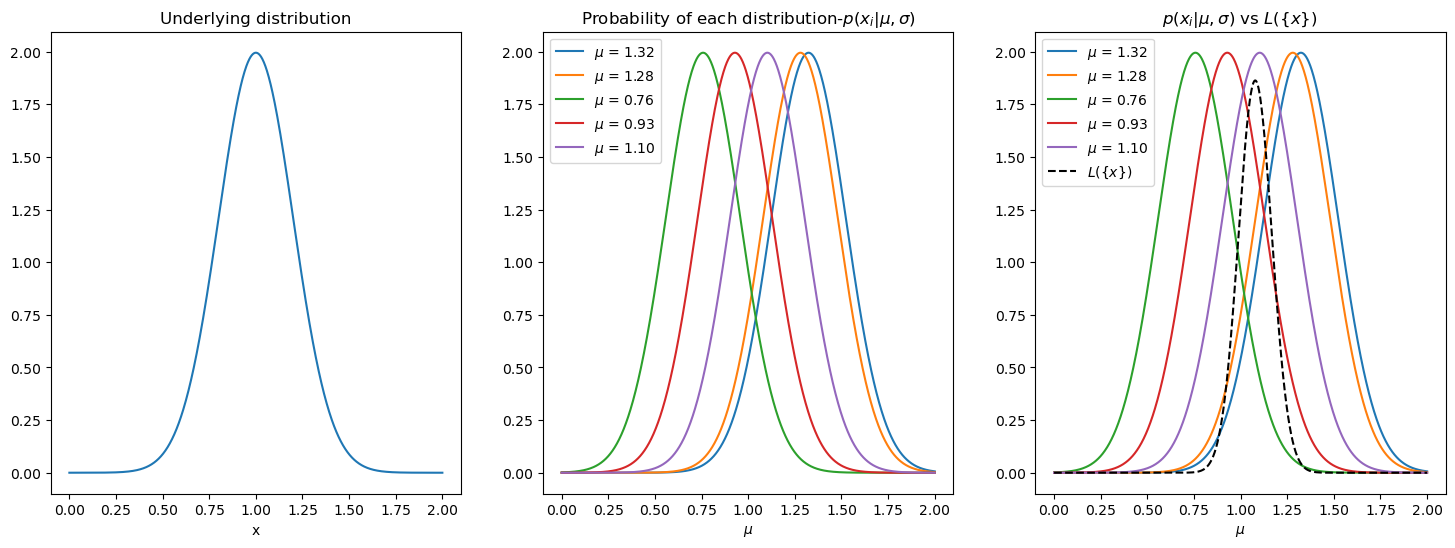

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Generate data from a gaussian process with true position \mu= 1 and errors \sigma=0
mean = 1
sigma = 0.2
size = 1000
N = 5

underlying_process = scipy.stats.norm(loc = mean, scale = sigma)
xgrid = np.linspace(0,2,size)

ax[0].set_title("Underlying distribution")
ax[0].plot(xgrid,underlying_process.pdf(xgrid))
ax[0].set_xlabel("x")

#Compute the probability of each  data point. I draw N= 5 points from the underlyibg process
x = scipy.stats.norm.rvs(loc = mean, scale = sigma,size= N)


tot_likelihood = 1 #Plot the product of the $p(x_i |\mu,\sigma)$, so the Likelihood.

for mu in x:
    likelihood = scipy.stats.norm(loc=mu, scale=sigma)
    ax[1].plot(xgrid, likelihood.pdf(xgrid), label = "$\mu$ = %.02f"%mu)
    ax[2].plot(xgrid, likelihood.pdf(xgrid), label = "$\mu$ = %.02f"%mu)
    #Plot the product of the $p(x_i |\mu,\sigma)$, so the Likelihood.
    tot_likelihood = likelihood.pdf(xgrid) * tot_likelihood


ax[1].set_title("Probability of each distribution-$p(x_i |\mu,\sigma)$")
ax[1].set_xlabel("$\mu$")
ax[1].legend()

ax[2].plot(xgrid, tot_likelihood,label= "$L(\{x\})$", ls='--',c='black')
ax[2].set_title("$p(x_i |\mu,\sigma)$ vs $L(\{x\})$ ")
ax[2].set_xlabel("$\mu$")
ax[2].legend()



#### 2)
- Just read off the maximum likelihood solution (e.g. using np.argsort )

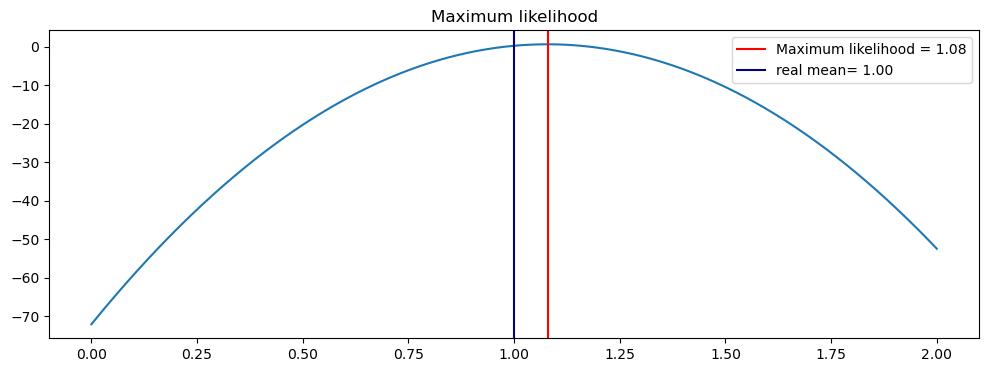

In [3]:
# Compute the maximum likelihood.
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

tot_likelihood = np.log(tot_likelihood)
max_likelihood = xgrid[np.argmax(tot_likelihood)]

ax.plot(xgrid, tot_likelihood)
ax.axvline(max_likelihood, c="red", label="Maximum likelihood = %.02f"%max_likelihood)
ax.axvline(mean, c="navy", label= "real mean= %0.2f"%mean)
ax.set_title("Maximum likelihood")
ax.legend()

- Comparison between Maximum Likelihood, Fisher Matrix and cooresponding MLE estimators

In [4]:
#compute the MLE estimator with its error.
MLest = np.mean(x)
MLEsigma =sigma/N**0.5

#Compute the maximum likelihood value with its error using the fisher matrix.
sigma_mu = np.diff(np.log(tot_likelihood), n = 2) #n is equal to 2 because I want the 2° derivative
sigma_mu /= (xgrid[1] - xgrid[0])**2
sigma_mu *= -1
sigma_mu = 1/np.sqrt(sigma_mu)[np.argmax(tot_likelihood)]


###############################################################
print("Maximum likelihod estimator:")
print("------------------------------------")
print("MLest = %0.2f"%MLest,"|","MLEsigma = %0.2f"%MLEsigma," |")
print("\n")
print("Maximum likelihod:")
print("------------------------------------")
print("MaxL= %0.2f"%max_likelihood,"  |","MaxLsigma = %0.2f"%sigma_mu,"|")

Maximum likelihod estimator:
------------------------------------
MLest = 1.08 | MLEsigma = 0.09  |


Maximum likelihod:
------------------------------------
MaxL= 1.08   | MaxLsigma = 0.07 |


C:\Users\utente\AppData\Local\Temp\ipykernel_11880\1733590760.py:6: RuntimeWarning: invalid value encountered in log
  sigma_mu = np.diff(np.log(tot_likelihood), n = 2) #n is equal to 2 because I want the 2° derivative


- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution.

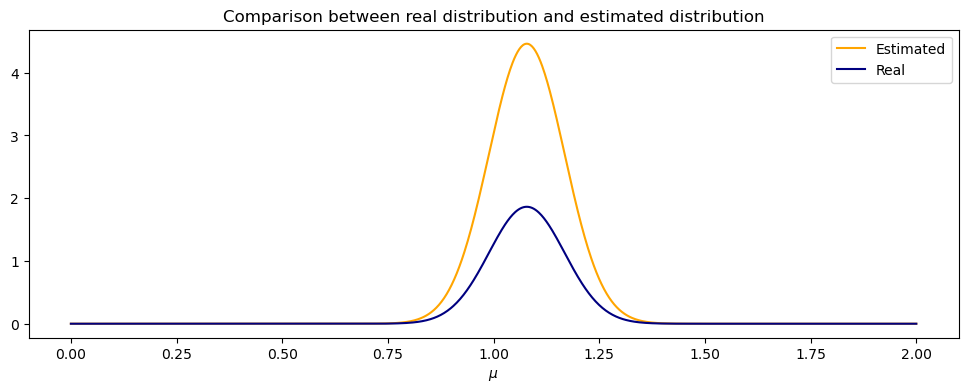

In [5]:
#Plot the real distribution versus te estimated one
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

estimated_gaussian = scipy.stats.norm(loc = MLest, scale = MLEsigma)

ax.plot(xgrid,estimated_gaussian.pdf(xgrid),c='orange', ls='-', label = 'Estimated')
ax.plot(xgrid,np.exp(tot_likelihood),c='navy', ls='-', label = 'Real')
ax.set_title("Comparison between real distribution and estimated distribution")
ax.set_xlabel("$\mu$")
ax.legend()

# Part 2 - heteroscedastic case

- Let's make our model more realistic. Our N measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distribured with mean 0.2 and standard deviation 0.05.

Generalize your code from above to this case

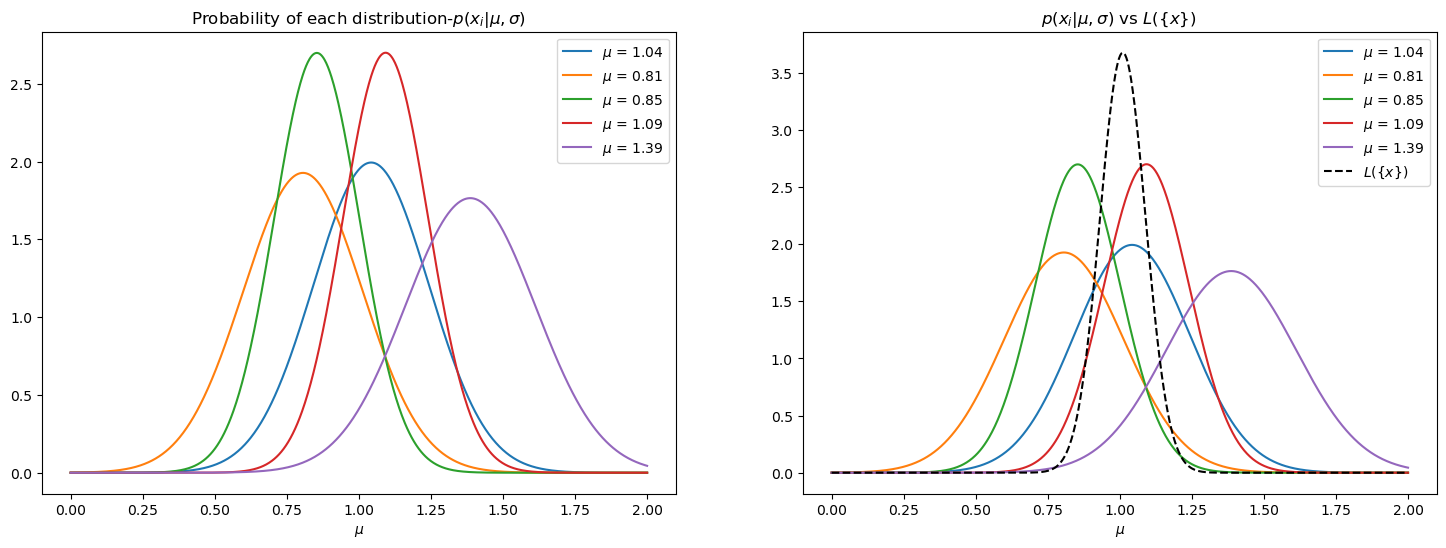

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

#Compute the probability of each  data point. I draw N= 5 points from the underlyibg process
sigma_i = scipy.stats.norm.rvs(loc = 0.2, scale = 0.05, size=N)
x = scipy.stats.norm.rvs(loc = mean, scale = sigma_i,size= N)

tot_likelihood = 1 #Plot the product of the $p(x_i |\mu,\sigma)$, so the Likelihood.

for mu,sigma in zip(x,sigma_i):
    likelihood = scipy.stats.norm(loc=mu, scale=sigma)
    ax[0].plot(xgrid, likelihood.pdf(xgrid), label = "$\mu$ = %0.2f"%mu,)
    ax[1].plot(xgrid, likelihood.pdf(xgrid), label = "$\mu$ = %0.2f"%mu)
    #Plot the product of the $p(x_i |\mu,\sigma)$, so the Likelihood.
    tot_likelihood = likelihood.pdf(xgrid) * tot_likelihood


ax[0].set_title("Probability of each distribution-$p(x_i |\mu,\sigma)$")
ax[0].set_xlabel("$\mu$")
ax[0].legend()

ax[1].plot(xgrid, tot_likelihood,label= "$L(\{x\})$", ls='--',c='black')
ax[1].set_title("$p(x_i |\mu,\sigma)$ vs $L(\{x\})$ ")
ax[1].set_xlabel("$\mu$")
ax[1].legend()



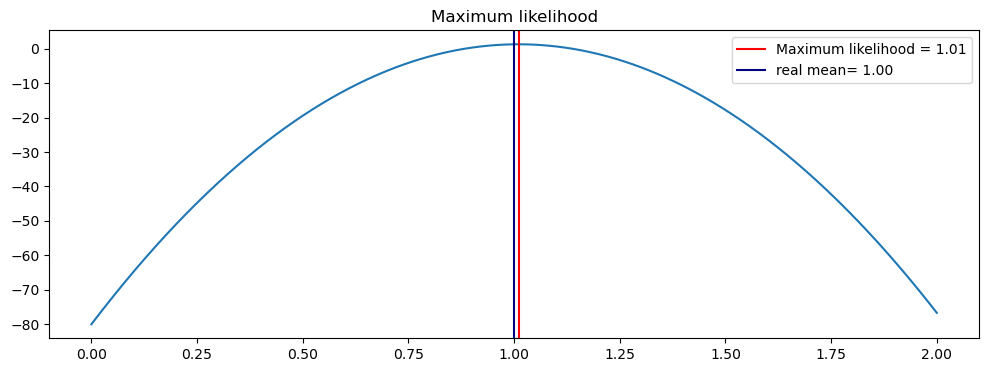

In [7]:
# Compute the maximum likelihood.
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

tot_likelihood = np.log(tot_likelihood)
max_likelihood = xgrid[np.argmax(tot_likelihood)]

ax.plot(xgrid, tot_likelihood)
ax.axvline(max_likelihood, c="red", label="Maximum likelihood = %.02f"%max_likelihood)
ax.axvline(mean, c="navy", label= "real mean= %0.2f"%mean)
ax.set_title("Maximum likelihood")
ax.legend()

In [8]:
#compute the MLE estimator with its error.
MLest = np.average(x, weights= 1/sigma_i**2)
MLEsigma =(np.sum(1/sigma_i))**(-1/2)

#Compute the maximum likelihood value with its error using the fisher matrix.
sigma_mu = np.diff(np.log(tot_likelihood), n = 2) #n is equal to 2 because I want the 2° derivative
sigma_mu /= (xgrid[1] - xgrid[0])**2
sigma_mu *= -1
sigma_mu = 1/np.sqrt(sigma_mu)[np.argmax(tot_likelihood)]


###############################################################
print("Maximum likelihod estimator:")
print("------------------------------------")
print("MLest = %0.2f"%MLest,"|","MLEsigma = %0.2f"%MLEsigma," |")
print("\n")
print("Maximum likelihod:")
print("------------------------------------")
print("MaxL= %0.2f"%max_likelihood,"  |","MaxLsigma = %0.2f"%sigma_mu,"|")

Maximum likelihod estimator:
------------------------------------
MLest = 1.01 | MLEsigma = 0.19  |


Maximum likelihod:
------------------------------------
MaxL= 1.01   | MaxLsigma = 0.09 |


C:\Users\utente\AppData\Local\Temp\ipykernel_11880\3172523039.py:6: RuntimeWarning: invalid value encountered in log
  sigma_mu = np.diff(np.log(tot_likelihood), n = 2) #n is equal to 2 because I want the 2° derivative


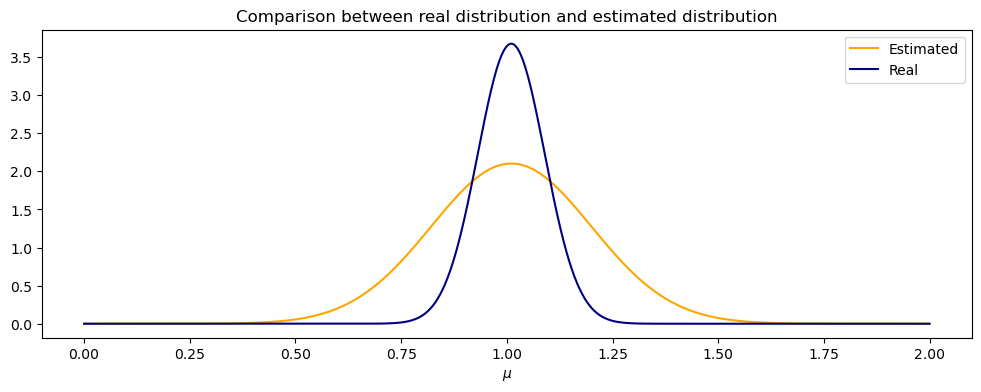

In [9]:
#Plot the real distribution versus te estimated one
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

estimated_gaussian = scipy.stats.norm(loc = MLest, scale = MLEsigma)

ax.plot(xgrid,estimated_gaussian.pdf(xgrid),c='orange', ls='-', label = 'Estimated')
ax.plot(xgrid,np.exp(tot_likelihood),c='navy', ls='-', label = 'Real')
ax.set_title("Comparison between real distribution and estimated distribution")
ax.set_xlabel("$\mu$")
ax.legend()